In [70]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from core.data import load_from_kaggle


In [71]:
dataset_link = "oles04/bundesliga-seasons" # replace with your dataset link from Kaggle 
destination = os.path.join('..', 'data','buli_05_to_23', 'raw')


dataset_name = dataset_link.split("/")[-1]

file = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '..\data\buli_05_to_23\raw\bundesliga-seasons' already exists with files. Skipping download (replace=False).


In [72]:
file
filename = file[0]

In [73]:
file
dataset_folder = os.path.join(destination, dataset_name)

csv_path = os.path.join(dataset_folder,filename)


In [74]:
df = pd.read_csv(csv_path)
df.head()

,Unnamed: 0,MATCH_DATE,LEAGUE_NAME,SEASON,LEAGUE,FINISHED,LOCATION,VIEWER,MATCHDAY,MATCHDAY_NR,...,HOME_ICON,AWAY_TEAM_ID,AWAY_TEAM_NAME,AWAY_TEAM,AWAY_ICON,GOALS_HOME,GOALS_AWAY,DRAW,WIN_HOME,WIN_AWAY
0,0,2005-08-05 20:30:00,1. Fussball-Bundesliga 2005/2006,2005,bl1,True,München,NaN,1. Spieltag,1,...,https://i.imgur.com/jJEsJrj.png,87,Borussia Mönchengladbach,Gladbach,https://i.imgur.com/KSIk0Eu.png,3,0,0.0,1.0,0.0
1,1,2005-08-06 15:30:00,1. Fussball-Bundesliga 2005/2006,2005,bl1,True,Köln,NaN,1. Spieltag,1,...,https://upload.wikimedia.org/wikipedia/en/thum...,81,1. FSV Mainz 05,Mainz,https://upload.wikimedia.org/wikipedia/commons...,1,0,0.0,1.0,0.0
2,2,2005-08-06 15:30:00,1. Fussball-Bundesliga 2005/2006,2005,bl1,True,Duisburg,NaN,1. Spieltag,1,...,https://upload.wikimedia.org/wikipedia/en/c/c8...,16,VfB Stuttgart,Stuttgart,https://i.imgur.com/v0tkpNx.png,1,1,1.0,0.0,0.0
3,3,2005-08-06 15:30:00,1. Fussball-Bundesliga 2005/2006,2005,bl1,True,Hamburg,NaN,1. Spieltag,1,...,https://upload.wikimedia.org/wikipedia/commons...,79,1. FC Nürnberg,Nürnberg,https://upload.wikimedia.org/wikipedia/commons...,3,0,0.0,1.0,0.0
4,4,2005-08-06 15:30:00,1. Fussball-Bundesliga 2005/2006,2005,bl1,True,Wolfsburg,NaN,1. Spieltag,1,...,https://i.imgur.com/ucqKV4B.png,7,Borussia Dortmund,BVB,https://upload.wikimedia.org/wikipedia/commons...,2,2,1.0,0.0,0.0


## eda

In [75]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(5508, 23)

'Description'

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5508.0,2755.06,1590.77,0.0,1378.75,2755.5,4132.25,5509.0
SEASON,5508.0,2013.50,5.19,2005.0,2009.00,2013.5,2018.00,2022.0
VIEWER,1682.0,41841.02,18057.42,0.0,28176.25,41000.0,52121.00,81365.0
MATCHDAY_NR,5508.0,17.50,9.81,1.0,9.00,17.5,26.00,34.0
HOME_TEAM_ID,5508.0,109.76,231.49,6.0,40.00,81.0,112.00,1635.0
AWAY_TEAM_ID,5508.0,109.76,231.49,6.0,40.00,81.0,112.00,1635.0
GOALS_HOME,5508.0,1.39,1.30,0.0,0.00,1.0,2.00,9.0
GOALS_AWAY,5508.0,1.08,1.13,0.0,0.00,1.0,2.00,8.0
DRAW,5508.0,0.29,0.45,0.0,0.00,0.0,1.00,1.0
WIN_HOME,5508.0,0.43,0.49,0.0,0.00,0.0,1.00,1.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
Unnamed: 0,int64,0,5508,"[302, 4626, 1633]"
MATCH_DATE,object,0,2603,"[2016-10-15 15:30:00, 2022-11-05 15:30:00, 200..."
LEAGUE_NAME,object,0,18,"[1. Fussball-Bundesliga 2009/2010, 1. Fussball..."
SEASON,int64,0,18,"[2011, 2005, 2018]"
LEAGUE,object,0,1,"[bl1, bl1, bl1]"
FINISHED,bool,0,1,"[True, True, True]"
LOCATION,object,0,33,"[Wolfsburg, Berlin, Stuttgart]"
VIEWER,float64,3826,814,"[52000.0, nan, nan]"
MATCHDAY,object,0,34,"[24. Spieltag, 32. Spieltag, 9. Spieltag]"
MATCHDAY_NR,int64,0,34,"[31, 29, 9]"


In [76]:
df.columns

Index(['Unnamed: 0', 'MATCH_DATE', 'LEAGUE_NAME', 'SEASON', 'LEAGUE',
       'FINISHED', 'LOCATION', 'VIEWER', 'MATCHDAY', 'MATCHDAY_NR',
       'HOME_TEAM_ID', 'HOME_TEAM_NAME', 'HOME_TEAM', 'HOME_ICON',
       'AWAY_TEAM_ID', 'AWAY_TEAM_NAME', 'AWAY_TEAM', 'AWAY_ICON',
       'GOALS_HOME', 'GOALS_AWAY', 'DRAW', 'WIN_HOME', 'WIN_AWAY'],
      dtype='object')

In [77]:
# df = df.drop(columns='Unnamed: 0')

display(df.loc[:,['HOME_TEAM_ID', 'HOME_TEAM_NAME', 'HOME_TEAM', 'HOME_ICON',
       'AWAY_TEAM_ID', 'AWAY_TEAM_NAME', 'AWAY_TEAM', 'AWAY_ICON']])

,HOME_TEAM_ID,HOME_TEAM_NAME,HOME_TEAM,HOME_ICON,AWAY_TEAM_ID,AWAY_TEAM_NAME,AWAY_TEAM,AWAY_ICON
0,40,FC Bayern München,Bayern,https://i.imgur.com/jJEsJrj.png,87,Borussia Mönchengladbach,Gladbach,https://i.imgur.com/KSIk0Eu.png
1,65,1. FC Köln,Köln,https://upload.wikimedia.org/wikipedia/en/thum...,81,1. FSV Mainz 05,Mainz,https://upload.wikimedia.org/wikipedia/commons...
2,107,MSV Duisburg,Duisburg,https://upload.wikimedia.org/wikipedia/en/c/c8...,16,VfB Stuttgart,Stuttgart,https://i.imgur.com/v0tkpNx.png
3,100,Hamburger SV,HSV,https://upload.wikimedia.org/wikipedia/commons...,79,1. FC Nürnberg,Nürnberg,https://upload.wikimedia.org/wikipedia/commons...
4,131,VfL Wolfsburg,Wolfsburg,https://i.imgur.com/ucqKV4B.png,7,Borussia Dortmund,BVB,https://upload.wikimedia.org/wikipedia/commons...
...,...,...,...,...,...,...,...,...
5503,65,1. FC Köln,Köln,https://upload.wikimedia.org/wikipedia/en/thum...,40,FC Bayern München,Bayern,https://i.imgur.com/jJEsJrj.png
5504,1635,RB Leipzig,Leipzig,https://i.imgur.com/Rpwsjz1.png,9,FC Schalke 04,Schalke,https://upload.wikimedia.org/wikipedia/commons...
5505,16,VfB Stuttgart,Stuttgart,https://i.imgur.com/v0tkpNx.png,175,TSG 1899 Hoffenheim,Hoffenheim,https://i.imgur.com/gF0PfEl.png
5506,80,1. FC Union Berlin,Union Berlin,https://assets.dfb.de/uploads/000/018/232/smal...,134,Werder Bremen,Bremen,https://upload.wikimedia.org/wikipedia/commons...


In [78]:
df = df.loc[:,['MATCH_DATE', 'SEASON','LOCATION','MATCHDAY_NR','HOME_TEAM_NAME','AWAY_TEAM_NAME','GOALS_HOME', 'GOALS_AWAY', 'DRAW', 'WIN_HOME', 'WIN_AWAY']]
type(df)

display(df.loc[:,'SEASON'].nunique())
display(df.loc[:,'SEASON'].unique())

18

array([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [79]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })

'Shape'

(5508, 11)

'Description'

,count,mean,std,min,25%,50%,75%,max
SEASON,5508.0,2013.50,5.19,2005.0,2009.0,2013.5,2018.0,2022.0
MATCHDAY_NR,5508.0,17.50,9.81,1.0,9.0,17.5,26.0,34.0
GOALS_HOME,5508.0,1.39,1.30,0.0,0.0,1.0,2.0,9.0
GOALS_AWAY,5508.0,1.08,1.13,0.0,0.0,1.0,2.0,8.0
DRAW,5508.0,0.29,0.45,0.0,0.0,0.0,1.0,1.0
WIN_HOME,5508.0,0.43,0.49,0.0,0.0,0.0,1.0,1.0
WIN_AWAY,5508.0,0.28,0.45,0.0,0.0,0.0,1.0,1.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
MATCH_DATE,object,0,2603,"[2011-09-24 15:30:00, 2009-04-04 15:30:00, 201..."
SEASON,int64,0,18,"[2016, 2015, 2010]"
LOCATION,object,0,33,"[Gelsenkirchen, Kaiserslautern, München]"
MATCHDAY_NR,int64,0,34,"[27, 16, 21]"
HOME_TEAM_NAME,object,0,35,"[SC Freiburg, Borussia Dortmund, Borussia Dort..."
AWAY_TEAM_NAME,object,0,35,"[1. FC Union Berlin, RB Leipzig, TSG 1899 Hoff..."
GOALS_HOME,int64,0,10,"[1, 0, 3]"
GOALS_AWAY,int64,0,9,"[2, 4, 0]"
DRAW,float64,0,2,"[1.0, 0.0, 1.0]"
WIN_HOME,float64,0,2,"[0.0, 0.0, 0.0]"


In [80]:
df.loc[:,'DRAW'] = df.loc[:,'DRAW'].astype('int')
df.loc[:,'WIN_HOME'] = df.loc[:,'WIN_HOME'].astype('int')
df.loc[:,'WIN_AWAY'] = df.loc[:,'WIN_AWAY'].astype('int')

# maybe cast as categories later

In [81]:
# make sure team names are consistent

# get list of unique home teams

home_teams = df['HOME_TEAM_NAME'].unique().tolist()
home_teams = sorted(home_teams)
away_teams = df['AWAY_TEAM_NAME'].unique().tolist()
away_teams = sorted(away_teams)

home_teams == away_teams

True

In [82]:
# change season 

season_list = sorted(df['SEASON'].unique().tolist())
season_list

correct_season = ['05_06', '06_07', '07_08', '08_09', '09_10', '10_11', '11_12',
                  '12_13', '13_14', '14_15', '15_16', '16_17', '17_18', '18_19',
                   '19_20', '20_21', '21_22', '22_23']

season_map = dict(zip(season_list, correct_season))
season_map

df['SEASON'] = df['SEASON'].replace(season_map)

df['SEASON'].unique()

array(['05_06', '06_07', '07_08', '08_09', '09_10', '10_11', '11_12',
       '12_13', '13_14', '14_15', '15_16', '16_17', '17_18', '18_19',
       '19_20', '20_21', '21_22', '22_23'], dtype=object)

## get data for final bundesliga rankings

In [83]:
# get final rankings

'''"eliasmarcon/german-bundesliga-chronicles"'''

'"eliasmarcon/german-bundesliga-chronicles"'

In [84]:
dataset_link = "eliasmarcon/german-bundesliga-chronicles" # replace with your dataset link from Kaggle 
destination = os.path.join('..', 'data','buli_final_tables', 'raw')


dataset_name = dataset_link.split("/")[-1]

folders = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '..\data\buli_final_tables\raw\german-bundesliga-chronicles' already exists with files. Skipping download (replace=False).


In [87]:
folders
csv_final_table = os.path.join(destination, dataset_name, folders[0], '1_bundesliga_final_table.csv')

df_final_table = pd.read_csv(csv_final_table)

In [89]:
df_final_table.head()

,League,Season,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff
0,1. Bundesliga,2004/2005,FC Bayern München,Bayern,34,77,24,5,5,75,33,42
1,1. Bundesliga,2004/2005,FC Schalke 04,Schalke,34,63,20,11,3,56,46,10
2,1. Bundesliga,2004/2005,Werder Bremen,Bremen,34,59,18,11,5,68,37,31
3,1. Bundesliga,2004/2005,Hertha BSC,Hertha,34,58,15,6,13,59,31,28
4,1. Bundesliga,2004/2005,VfB Stuttgart,Stuttgart,34,58,17,10,7,54,40,14


In [91]:
display(
    "Shape",
    df_final_table.shape,
    "Description",
    df_final_table.describe().round(2).T,
    "Duplicates",
    df_final_table.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df_final_table.dtypes,
        "Missing Values": df_final_table.isnull().sum(),
        "Unique Values": df_final_table.nunique(),
        "Sample Values": [df_final_table[col].sample(3).tolist() for col in df_final_table.columns]
    })

'Shape'

(378, 12)

'Description'

,count,mean,std,min,25%,50%,75%,max
Matches,378.0,33.56,1.97,24.0,34.0,34.0,34.00,34.0
Points,378.0,46.17,14.60,14.0,36.0,43.0,55.00,91.0
Won,378.0,12.61,5.16,3.0,9.0,12.0,15.00,29.0
Lost,378.0,12.61,4.65,0.0,9.0,13.0,16.00,24.0
Draw,378.0,8.34,2.73,3.0,6.0,8.0,10.00,17.0
Goals,378.0,49.67,15.41,19.0,39.0,47.0,57.75,100.0
Opponent_Goals,378.0,49.67,11.93,17.0,42.0,50.0,57.00,86.0
GoalDiff,378.0,0.00,23.53,-61.0,-16.0,-3.5,13.00,80.0


'Duplicates'

np.int64(0)

,Data Types,Missing Values,Unique Values,Sample Values
League,object,0,1,"[1. Bundesliga, 1. Bundesliga, 1. Bundesliga]"
Season,object,0,21,"[2014/2015, 2010/2011, 2011/2012]"
Team,object,0,37,"[Karlsruher SC, Bayer Leverkusen, TSG 1899 Hof..."
Team_Short,object,0,38,"[Stuttgart, Union Berlin, Rostock]"
Matches,int64,0,3,"[34, 34, 34]"
Points,int64,0,69,"[33, 76, 41]"
Won,int64,0,27,"[21, 9, 22]"
Lost,int64,0,25,"[17, 19, 14]"
Draw,int64,0,15,"[9, 8, 5]"
Goals,int64,0,71,"[33, 43, 39]"


In [93]:
df_final_table['Season'].unique()

array(['2004/2005', '2005/2006', '2006/2007', '2007/2008', '2008/2009',
       '2009/2010', '2010/2011', '2011/2012', '2012/2013', '2013/2014',
       '2014/2015', '2015/2016', '2016/2017', '2017/2018', '2018/2019',
       '2019/2020', '2020/2021', '2021/2022', '2022/2023', '2023/2024',
       '2024/2025'], dtype=object)

## eda and datacleaning final rankings

In [ ]:
# make season namings consistent with df for matches

#df_final_table = df_final_table.rename(columns={'Season': 'SEASON'})
season_list = sorted(df_final_table['SEASON'].unique().tolist())
season_list

correct_season = ['04_05','05_06', '06_07', '07_08', '08_09', '09_10', '10_11', '11_12',
                  '12_13', '13_14', '14_15', '15_16', '16_17', '17_18', '18_19',
                   '19_20', '20_21', '21_22', '22_23','23_24', '24_25']

season_map = dict(zip(season_list, correct_season))
season_map

df_final_table['SEASON'] = df_final_table['SEASON'].replace(season_map)

df_final_table['SEASON'].unique()

array(['04_05', '05_06', '06_07', '07_08', '08_09', '09_10', '10_11',
       '11_12', '12_13', '13_14', '14_15', '15_16', '16_17', '17_18',
       '18_19', '19_20', '20_21', '21_22', '22_23', '23_24', '24_25'],
      dtype=object)

In [99]:
# check team names

df_matches = df.copy()

df_matches.head()

matches_team_names = sorted(df_matches['HOME_TEAM_NAME'].unique().tolist())
rankings_team_names = sorted(df_final_table['Team'].unique().tolist())

display(matches_team_names)
display(rankings_team_names)


['1. FC Kaiserslautern',
 '1. FC Köln',
 '1. FC Nürnberg',
 '1. FC Union Berlin',
 '1. FSV Mainz 05',
 'Alemannia Aachen',
 'Arminia Bielefeld',
 'Bayer Leverkusen',
 'Borussia Dortmund',
 'Borussia Mönchengladbach',
 'Eintracht Braunschweig',
 'Eintracht Frankfurt',
 'FC Augsburg',
 'FC Bayern München',
 'FC Energie Cottbus',
 'FC Hansa Rostock',
 'FC Ingolstadt 04',
 'FC Schalke 04',
 'FC St. Pauli',
 'Fortuna Düsseldorf',
 'Hamburger SV',
 'Hannover 96',
 'Hertha BSC',
 'Karlsruher SC',
 'MSV Duisburg',
 'RB Leipzig',
 'SC Freiburg',
 'SC Paderborn 07',
 'SV Darmstadt 98',
 'SpVgg Greuther Fürth',
 'TSG 1899 Hoffenheim',
 'VfB Stuttgart',
 'VfL Bochum',
 'VfL Wolfsburg',
 'Werder Bremen']

['1. FC Heidenheim 1846',
 '1. FC Kaiserslautern',
 '1. FC Köln',
 '1. FC Nürnberg',
 '1. FC Union Berlin',
 '1. FSV Mainz 05',
 'Alemannia Aachen',
 'Arminia Bielefeld',
 'Bayer Leverkusen',
 'Borussia Dortmund',
 'Borussia Mönchengladbach',
 'Eintracht Braunschweig',
 'Eintracht Frankfurt',
 'FC Augsburg',
 'FC Bayern München',
 'FC Energie Cottbus',
 'FC Hansa Rostock',
 'FC Ingolstadt 04',
 'FC Schalke 04',
 'FC St. Pauli',
 'Fortuna Düsseldorf',
 'Hamburger SV',
 'Hannover 96',
 'Hertha BSC',
 'Holstein Kiel',
 'Karlsruher SC',
 'MSV Duisburg',
 'RB Leipzig',
 'SC Freiburg',
 'SC Paderborn 07',
 'SV Darmstadt 98',
 'SpVgg Greuther Fürth',
 'TSG 1899 Hoffenheim',
 'VfB Stuttgart',
 'VfL Bochum',
 'VfL Wolfsburg',
 'Werder Bremen']

In [102]:
identical_team_names = []
unmatched_team_names = []
remainder_rankings = rankings_team_names.copy()

for i in matches_team_names:

    if i in remainder_rankings:
        
        identical_team_names.append(i)
        remainder_rankings.remove(i)
    else:
        unmatched_team_names.append(i)
        

unmatched_team_names += remainder_rankings

unmatched_team_names

for team in unmatched_team_names:
    if team in rankings_team_names:
        print(f'{team} is in rankings')

1. FC Heidenheim 1846 is in rankings
Holstein Kiel is in rankings


In [104]:
# make sure away team names are identical to home team names in df_matches

matches_team_names_away = sorted(df_matches['AWAY_TEAM_NAME'].unique().tolist())

matches_team_names_away

matches_team_names_away == matches_team_names

True

In [107]:
df_unmatched_teams = df_final_table[(df_final_table['Team'] == '1. FC Heidenheim 1846') | (df_final_table['Team'] == 'Holstein Kiel')]

df_unmatched_teams

,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff
349,1. Bundesliga,23_24,1. FC Heidenheim 1846,Heidenheim,34,42,10,12,12,50,55,-5
376,1. Bundesliga,24_25,1. FC Heidenheim 1846,Heidenheim,25,16,4,17,4,28,51,-23
377,1. Bundesliga,24_25,Holstein Kiel,Kiel,24,14,3,16,5,36,61,-25


In [108]:
df_matches['SEASON'].max()

'22_23'

In [111]:
# looks like season 24_25 was not finished by the time the dataset was compiled
# delete this season from df_final_table

df_final_table = df_final_table[df_final_table['SEASON'] != '24_25']

df_final_table['Matches'].unique()

array([34])

0      FC Bayern München
1          FC Schalke 04
2          Werder Bremen
3             Hertha BSC
4          VfB Stuttgart
             ...        
342     Bayer Leverkusen
343        VfB Stuttgart
344    FC Bayern München
345           RB Leipzig
346    Borussia Dortmund
Name: Team, Length: 100, dtype: object

In [117]:
# what's nuts is that rankings are actually missing

# sort dataframe per season, pints, goal diff and goals

df_final_rankings = df_final_table.sort_values(
    by=['SEASON', 'Points', 'GoalDiff', 'Goals'],
    ascending=[True, False, False, False]
).copy()

df_final_rankings['Rank'] = df_final_rankings.groupby('SEASON').cumcount()+1

df_final_rankings.tail(20)

,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank
340,1. Bundesliga,22_23,FC Schalke 04,Schalke,34,31,7,17,10,35,71,-36,17
341,1. Bundesliga,22_23,Hertha BSC,Hertha,34,29,7,19,8,42,69,-27,18
342,1. Bundesliga,23_24,Bayer Leverkusen,Leverkusen,34,90,28,0,6,89,24,65,1
343,1. Bundesliga,23_24,VfB Stuttgart,Stuttgart,34,73,23,7,4,78,39,39,2
344,1. Bundesliga,23_24,FC Bayern München,Bayern,34,72,23,8,3,94,45,49,3
345,1. Bundesliga,23_24,RB Leipzig,Leipzig,34,65,19,7,8,77,39,38,4
346,1. Bundesliga,23_24,Borussia Dortmund,Dortmund,34,63,18,7,9,68,43,25,5
347,1. Bundesliga,23_24,Eintracht Frankfurt,Frankfurt,34,47,11,9,14,51,50,1,6
348,1. Bundesliga,23_24,TSG 1899 Hoffenheim,Hoffenheim,34,46,13,14,7,66,66,0,7
349,1. Bundesliga,23_24,1. FC Heidenheim 1846,Heidenheim,34,42,10,12,12,50,55,-5,8


In [120]:
### add initial ratings for Elo / Poisson / Dixon Cole treatment

df_final_rankings['Ratings_initial'] = 100 - (df_final_rankings['Rank']-1) * (99/17)

In [121]:
display(df_final_rankings.head(20))
display(df_final_rankings.tail(20))

,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank,Ratings_initial
0,1. Bundesliga,04_05,FC Bayern München,Bayern,34,77,24,5,5,75,33,42,1,100.000000
1,1. Bundesliga,04_05,FC Schalke 04,Schalke,34,63,20,11,3,56,46,10,2,94.176471
2,1. Bundesliga,04_05,Werder Bremen,Bremen,34,59,18,11,5,68,37,31,3,88.352941
3,1. Bundesliga,04_05,Hertha BSC,Hertha,34,58,15,6,13,59,31,28,4,82.529412
4,1. Bundesliga,04_05,VfB Stuttgart,Stuttgart,34,58,17,10,7,54,40,14,5,76.705882
5,1. Bundesliga,04_05,Bayer Leverkusen,Leverkusen,34,57,16,9,9,65,44,21,6,70.882353
6,1. Bundesliga,04_05,Borussia Dortmund,Dortmund,34,55,15,9,10,47,44,3,7,65.058824
7,1. Bundesliga,04_05,Hamburger SV,HSV,34,51,16,15,3,55,50,5,8,59.235294
8,1. Bundesliga,04_05,VfL Wolfsburg,Wolfsburg,34,48,15,16,3,49,51,-2,9,53.411765
9,1. Bundesliga,04_05,Hannover 96,Hannover,34,45,13,15,6,34,36,-2,10,47.588235


,League,SEASON,Team,Team_Short,Matches,Points,Won,Lost,Draw,Goals,Opponent_Goals,GoalDiff,Rank,Ratings_initial
340,1. Bundesliga,22_23,FC Schalke 04,Schalke,34,31,7,17,10,35,71,-36,17,6.823529
341,1. Bundesliga,22_23,Hertha BSC,Hertha,34,29,7,19,8,42,69,-27,18,1.000000
342,1. Bundesliga,23_24,Bayer Leverkusen,Leverkusen,34,90,28,0,6,89,24,65,1,100.000000
343,1. Bundesliga,23_24,VfB Stuttgart,Stuttgart,34,73,23,7,4,78,39,39,2,94.176471
344,1. Bundesliga,23_24,FC Bayern München,Bayern,34,72,23,8,3,94,45,49,3,88.352941
345,1. Bundesliga,23_24,RB Leipzig,Leipzig,34,65,19,7,8,77,39,38,4,82.529412
346,1. Bundesliga,23_24,Borussia Dortmund,Dortmund,34,63,18,7,9,68,43,25,5,76.705882
347,1. Bundesliga,23_24,Eintracht Frankfurt,Frankfurt,34,47,11,9,14,51,50,1,6,70.882353
348,1. Bundesliga,23_24,TSG 1899 Hoffenheim,Hoffenheim,34,46,13,14,7,66,66,0,7,65.058824
349,1. Bundesliga,23_24,1. FC Heidenheim 1846,Heidenheim,34,42,10,12,12,50,55,-5,8,59.235294


In [123]:
cwd = os.getcwd()
cwd

'c:\\Users\\Trainee.LAPTOP-7OL45FO7\\Desktop\\portfolio_projekt\\template_dsc\\notebooks'

In [128]:
processed_path = os.path.join('c:\\Users\\Trainee.LAPTOP-7OL45FO7\\Desktop\\portfolio_projekt\\template_dsc', 'data', 'processed')

if os.path.exists(processed_path):
    print('True')


# save final table

df_final_rankings.to_csv(os.path.join(processed_path, 'Bundesliga_Rankings.csv'), index=False)
df_matches.to_csv(os.path.join(processed_path, 'Bundesliga_Matches.csv'), index=False)

True


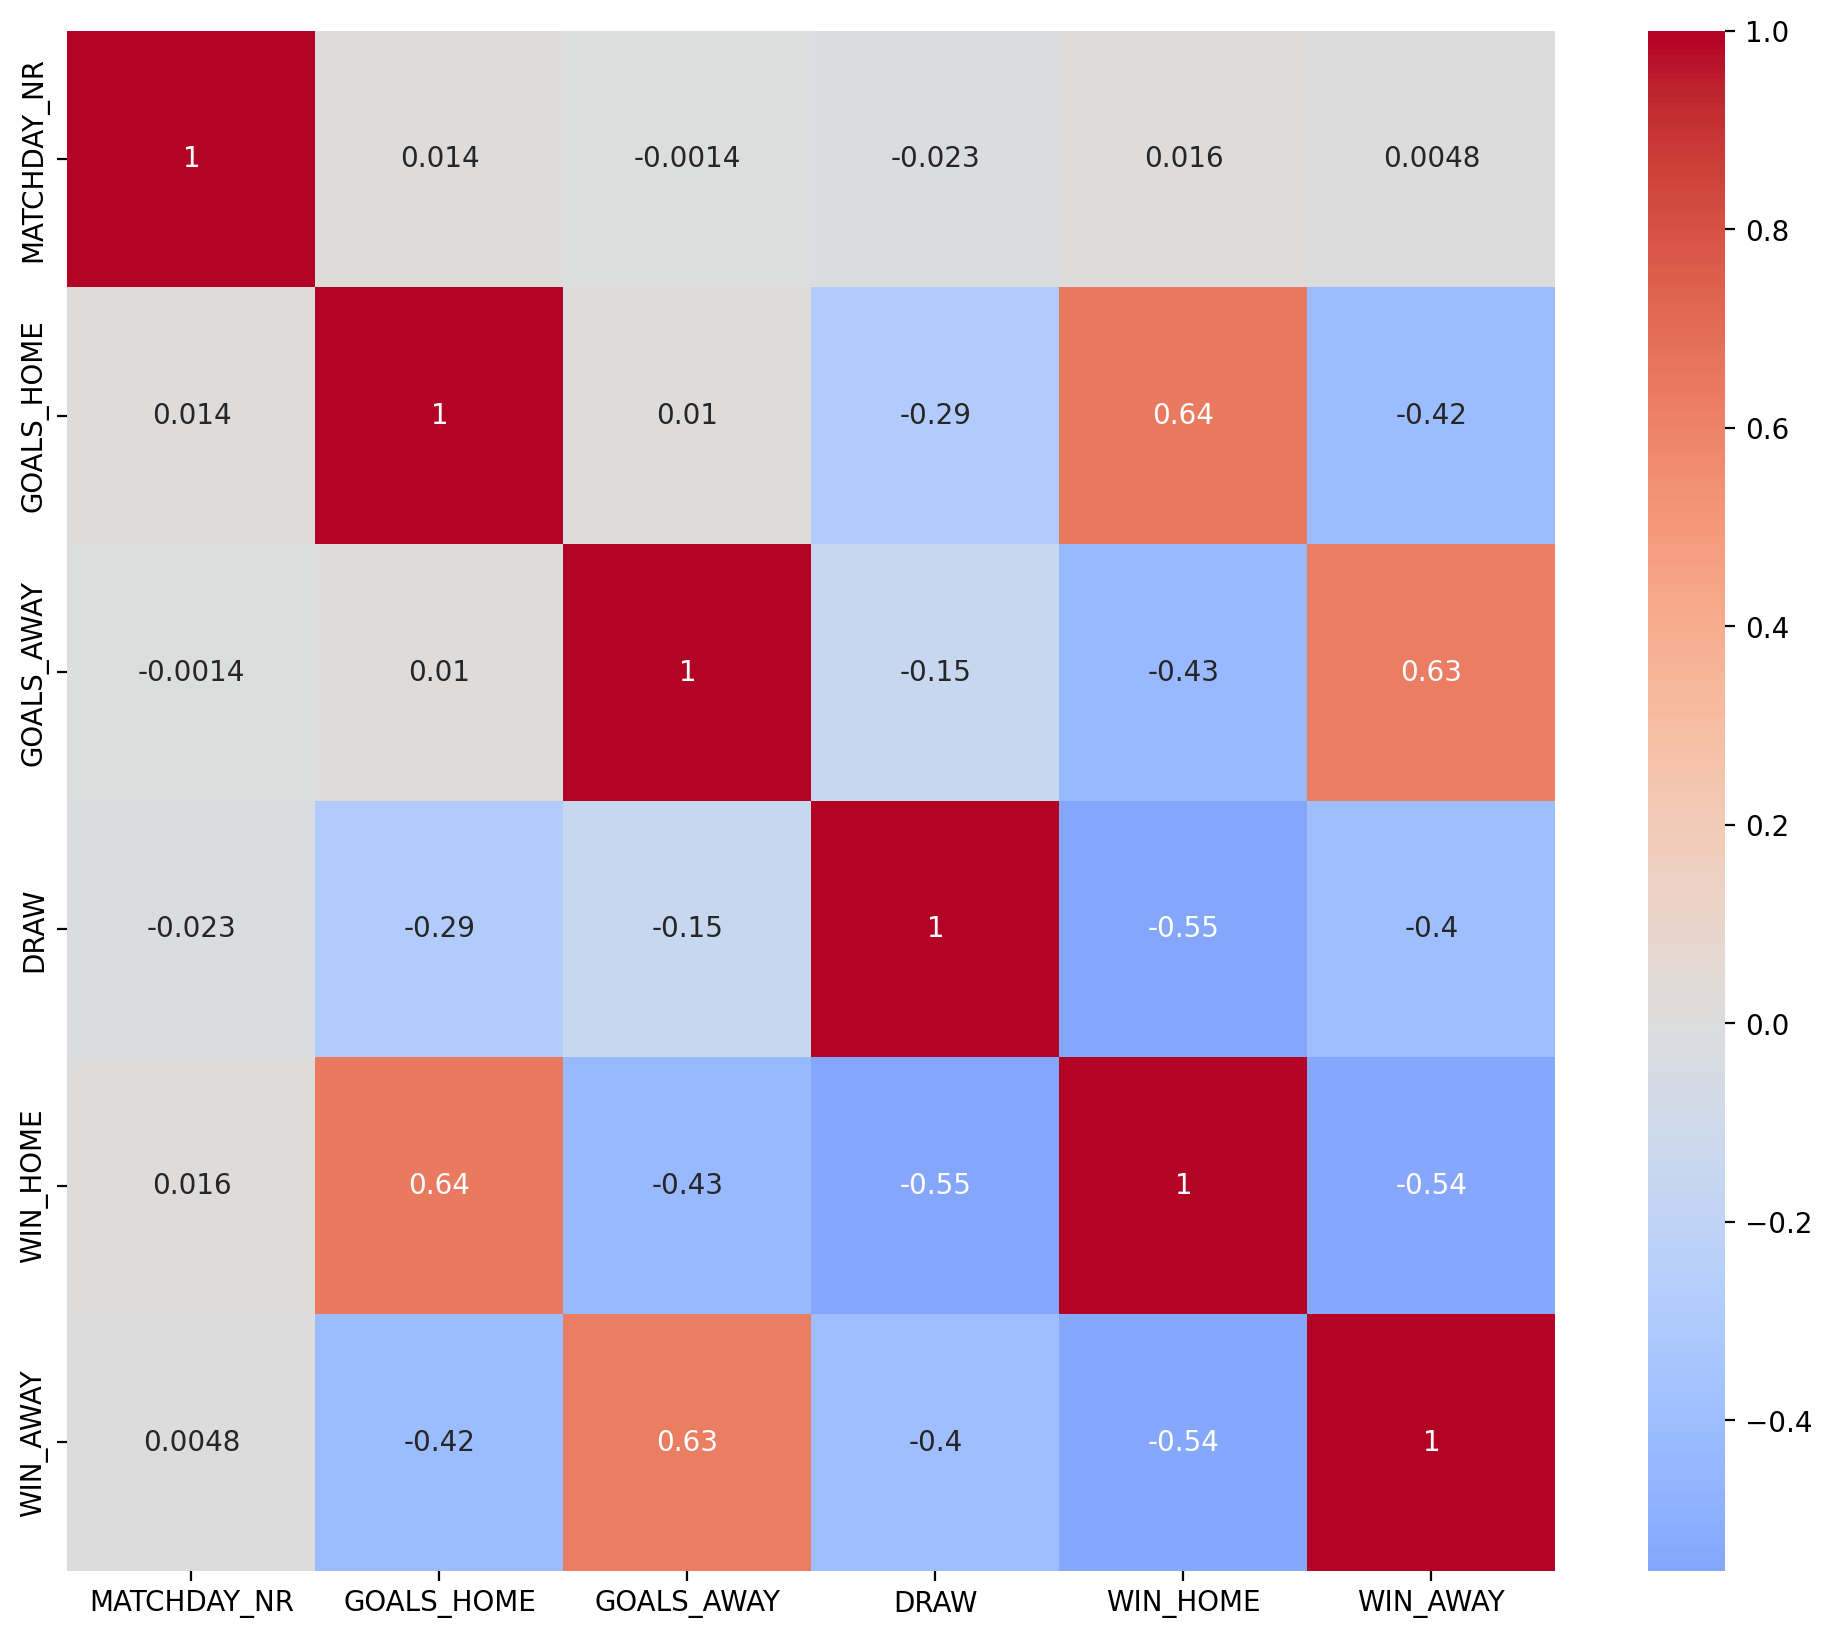

In [86]:

fig, ax = plt.subplots(figsize=(12, 10), dpi=200)

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, ax=ax);